# Archetypes and Defectors

### A deep dive into India's digital-payments heterogeneity (2018Q1 – 2024Q4)

---

**The question in one line.** India's digital-payments volume grew **~210×** in seven years — from ~134 M transactions per quarter in 2018Q1 to ~28.2 B in 2024Q4. Is this *one* national revolution, or do Indian districts actually occupy distinct behavioural archetypes — and if so, which districts *defy* their own archetype persistently enough to matter?

**The approach.** We answer this with a single, deep, two-phase analysis on the PhonePe Pulse dataset:

| Phase | Sub-question | Method |
|---|---|---|
| **WHO** are the archetypes? | Do districts group into a small number of interpretable behavioural archetypes, and how much do district *assignments* under that typology change across five years? | K-Means clustering on per-user normalised features, with fixed-centroid assignment-stability comparison between 2019Q4 and 2024Q4 |
| **WHERE** are the defectors? | Given a district's archetype, which districts persistently behave differently from their *own-tier peers* (not just from India overall)? | **Cluster-conditioned** anomaly detection: Isolation Forest + LOF + robust z-score run *within each tier × quarter*, contrasted with a global-peer baseline |

**Why these two merged, not three separate questions.** The two phases are **co-dependent**: anomaly detection is only meaningful once the peer-group definition (the archetype) is established. Running anomaly detection against the whole country flags *large* districts as outliers because they transact more — a scale effect, not behavioural deviance. Running it *within a district's own archetype* isolates the districts that truly defy their type. That second step is the deep-dive that a single-lens analysis cannot reach.

**The headline finding.** India's digital-payments landscape is **not uniform**. Districts fall into a small number of interpretable behavioural archetypes (a stable *structure* of three tiers), but district *membership* in those tiers churns considerably — roughly 60% of districts cross a tier boundary between 2019Q4 and 2024Q4. A small, well-defined watch-list of districts **persistently deviates from its archetype's norms**, and those early-period defectors *appear* over-represented among later movers (a suggestive +5 percentage-point lift in mobility, pending out-of-sample confirmation) — a candidate leading indicator rather than a confirmed one.

**Contents.** §1 Motivation → §2 The Question → §3 Data → §4 Setting the Scene → §5 Phase 1 (WHO — archetypes) → §6 Phase 2 (WHERE — defectors) → §7 Synthesis (archetypes × defectors × movers) → §8 Limitations → §9 Conclusions.


## 1. Motivation

India is the largest real-time-payments market in the world, and the PhonePe Pulse dataset is the most granular public window into that surge. Between 2018Q1 and 2024Q4 the platform observed **over 200× growth** in quarterly transaction volume, spanning **36 states/UTs** and **700+ districts**.

That growth is real — but it is **not the whole story**. Two facts from the raw data make the case that the aggregate number hides important heterogeneity:

- **State concentration.** The top 5 states account for roughly **half** of national transaction amount in every quarter of the panel.
- **District skew.** In 2024Q4, just **~270 out of ~790** observed districts produced **80%** of transaction value.

For a fintech deciding where to expand merchant acquisition, for a bank scoping UPI-linked credit products, for a policymaker designing a digital-inclusion programme, or for a risk team monitoring regional shocks, **"India" is not the right unit of analysis**. The right unit is the *archetype* — a group of districts that look similar in user behaviour — and the most interesting question inside each archetype is *which districts defy it*.

**Why cluster-conditioned anomaly detection is the load-bearing idea.** A naive "flag outliers across India" approach rewards *size* — it flags the country's largest cities as outliers simply because their absolute activity dwarfs the national median, a scale effect rather than behavioural deviance. What's interesting is the harder question: *given* that a district is in the top-tier archetype, which top-tier districts behave unusually for *top-tier* districts? Those are the real defectors — and, as we show in §6, they are disproportionately the ones that later change tier. This notebook formalises that question and answers it end-to-end.


## 2. The Question

### Big question
> **Do Indian districts cluster into a small, interpretable set of behavioural archetypes; how much do district assignments under that typology churn across five years; and which districts persistently defy their own archetype's norms — potentially foreshadowing mobility between archetypes?**

### Two merged sub-questions (one coherent deep-dive)
1. **WHO — Archetypes (Phase 1, Clustering).** Do Indian districts form a small, interpretable set of behavioural archetypes on user-normalised payment features? How many distinct archetypes, and — under a single fixed-centroid fit — how many districts receive the *same* tier assignment at both ends of the window versus how many cross a tier boundary?
2. **WHERE — Defectors (Phase 2, Cluster-conditioned Anomaly detection).** *Given* each district's assigned archetype, which districts persistently behave differently from their *own-archetype peers* — not just from India as a whole? And do those within-archetype defectors predict subsequent tier transitions?

### Why these are merged, not separate
Phase 2 is not independent of Phase 1: without a valid archetype assignment, "anomaly" collapses to "unusually large" or "unusually small." The clustering step *creates the peer group* against which anomaly detection is meaningful. This is why we report a **global-peer baseline** and a **within-archetype** result side-by-side — the difference quantifies how much of "anomaly" is just scale, and how much is true behavioural deviance.

### What success looks like
- A **named archetype map** describing each cluster in plain language, plus a transition matrix that quantifies mobility.
- A **baseline vs within-archetype comparison** showing how many "anomalies" from the naive approach are just scale artefacts.
- A **within-archetype watch-list** of districts persistently defying their own tier in ≥3 distinct quarters.
- A **mobility linkage** — an empirical test of whether within-archetype defection in early quarters predicts tier transitions by 2024Q4.
- A final **synthesis** that walks three real districts (a stable archetype-conformer, a mover, a defector) through both phases end-to-end.


## 3. Data and Features

**Source.** [PhonePe Pulse](https://github.com/PhonePe/pulse) — an open, CDLA-Permissive-2.0 release of aggregated payment statistics published by PhonePe.

**Grain.** Nested JSON files organised by `geography × year × quarter`. We use three complementary slices:
- `map/transaction` → state- and district-level transaction counts and amounts.
- `map/user` → state- and district-level registered users and app opens.
- `aggregated/transaction` → state-level payment-category breakdowns.

**Coverage.** 28 quarters (2018Q1 – 2024Q4), 36 states/UTs, 700+ districts.

**Design decision — per-user normalisation.** Raw transaction counts and amounts conflate **district size** (how many people live there) with **activity intensity** (how actively each user transacts). We normalise by registered users to separate these, producing the three features used throughout the notebook:

| Feature | Definition | Captures |
|---|---|---|
| `txns_per_user` | `txn_count / registered_users` | Transaction frequency per user |
| `amount_per_user` | `txn_amount / registered_users` | Spending intensity per user |
| `opens_per_user` | `app_opens / registered_users` | Engagement beyond payments |

This is the load-bearing preprocessing step for every downstream lens.


In [1]:
# --- Imports and configuration ----------------------------------------
import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
warnings.filterwarnings("ignore")

RNG = 42

PALETTE = {
    "blue": "#2c7fb8",
    "orange": "#e67e22",
    "green": "#31a354",
    "red": "#d62728",
    "purple": "#756bb1",
    "grey": "#7f7f7f",
}


In [2]:
# --- Dataset paths, parsers, and loader -------------------------------
# (Parsing logic is reused from the Milestone 1/2 notebooks. It is kept
# here unchanged so this notebook is self-contained and reproducible;
# the design decisions behind the parsers are documented in checkpoint_1.ipynb.)

PULSE_DIR = Path("pulse")
DATA_DIR = PULSE_DIR / "data"
MAP_TXN_COUNTRY_DIR = DATA_DIR / "map" / "transaction" / "hover" / "country" / "india"
MAP_TXN_STATE_DIR = MAP_TXN_COUNTRY_DIR / "state"
MAP_USER_COUNTRY_DIR = DATA_DIR / "map" / "user" / "hover" / "country" / "india"
MAP_USER_STATE_DIR = MAP_USER_COUNTRY_DIR / "state"
AGG_TXN_STATE_DIR = DATA_DIR / "aggregated" / "transaction" / "country" / "india" / "state"


def normalize_key(s):
    return re.sub(r"[^a-z0-9]+", "", str(s).lower())


def read_json(p):
    with p.open("r", encoding="utf-8") as f:
        return json.load(f)


def list_year_quarters(dir_):
    yq = []
    for year_dir in dir_.iterdir():
        if not year_dir.is_dir() or not year_dir.name.isdigit():
            continue
        y = int(year_dir.name)
        for f in year_dir.glob("*.json"):
            if f.stem.isdigit():
                q = int(f.stem)
                if 1 <= q <= 4:
                    yq.append((y, q))
    return sorted(set(yq))


def label(y, q):
    return f"{y}Q{q}"


def _parse_totals(entries, key_builder):
    out = []
    for entry in entries:
        total = next((m for m in entry.get("metric", []) if m.get("type") == "TOTAL"), None)
        if total is None:
            continue
        base = key_builder(entry)
        base["txn_count"] = float(total.get("count", 0.0))
        base["txn_amount"] = float(total.get("amount", 0.0))
        out.append(base)
    return out


def parse_map_txn_country(y, q):
    p = MAP_TXN_COUNTRY_DIR / str(y) / f"{q}.json"
    if not p.exists():
        return []
    return _parse_totals(
        read_json(p).get("data", {}).get("hoverDataList", []),
        lambda e: {
            "state_name": e.get("name"),
            "state_key": normalize_key(e.get("name")),
            "year": y,
            "quarter": q,
        },
    )


def parse_map_user_country(y, q):
    p = MAP_USER_COUNTRY_DIR / str(y) / f"{q}.json"
    if not p.exists():
        return []
    out = []
    for name, m in read_json(p).get("data", {}).get("hoverData", {}).items():
        out.append(
            {
                "state_name": name,
                "state_key": normalize_key(name),
                "year": y,
                "quarter": q,
                "registered_users": float(m.get("registeredUsers", 0.0)),
                "app_opens": float(m.get("appOpens", 0.0)),
            }
        )
    return out


def parse_map_txn_state_districts(slug, y, q):
    p = MAP_TXN_STATE_DIR / slug / str(y) / f"{q}.json"
    if not p.exists():
        return []
    return _parse_totals(
        read_json(p).get("data", {}).get("hoverDataList", []),
        lambda e: {
            "state_slug": slug,
            "state_key": normalize_key(slug),
            "district_name": e.get("name"),
            "district_key": normalize_key(e.get("name")),
            "year": y,
            "quarter": q,
        },
    )


def parse_map_user_state_districts(slug, y, q):
    p = MAP_USER_STATE_DIR / slug / str(y) / f"{q}.json"
    if not p.exists():
        return []
    hover = read_json(p).get("data", {}).get("hoverData", {})
    if not isinstance(hover, dict):
        return []
    out = []
    for name, m in hover.items():
        out.append(
            {
                "state_slug": slug,
                "state_key": normalize_key(slug),
                "district_name": name,
                "district_key": normalize_key(name),
                "year": y,
                "quarter": q,
                "registered_users": float(m.get("registeredUsers", 0.0)),
                "app_opens": float(m.get("appOpens", 0.0)),
            }
        )
    return out


def parse_agg_txn_state(slug, y, q):
    p = AGG_TXN_STATE_DIR / slug / str(y) / f"{q}.json"
    if not p.exists():
        return []
    out = []
    for entry in read_json(p).get("data", {}).get("transactionData", []):
        total = next((x for x in entry.get("paymentInstruments", []) if x.get("type") == "TOTAL"), None)
        if total is None:
            continue
        out.append(
            {
                "state_slug": slug,
                "state_key": normalize_key(slug),
                "category": entry.get("name"),
                "year": y,
                "quarter": q,
                "txn_count": float(total.get("count", 0.0)),
                "txn_amount": float(total.get("amount", 0.0)),
            }
        )
    return out


available_yq = list_year_quarters(MAP_TXN_COUNTRY_DIR)
state_slugs = sorted([p.name for p in AGG_TXN_STATE_DIR.iterdir() if p.is_dir()])
assert available_yq, "No quarters found. Ensure pulse/data is populated."
assert state_slugs, "No state slugs found. Ensure pulse/data/aggregated exists."

print(f"Quarters detected: {len(available_yq)} "
      f"({label(*available_yq[0])} to {label(*available_yq[-1])})")
print(f"State slugs detected: {len(state_slugs)}")


Quarters detected: 28 (2018Q1 to 2024Q4)
State slugs detected: 36


In [3]:
# --- Build the five core DataFrames -----------------------------------
txn_state_rows, user_state_rows = [], []
txn_district_rows, user_district_rows = [], []
agg_category_rows = []

for y, q in available_yq:
    txn_state_rows.extend(parse_map_txn_country(y, q))
    user_state_rows.extend(parse_map_user_country(y, q))
    for slug in state_slugs:
        txn_district_rows.extend(parse_map_txn_state_districts(slug, y, q))
        user_district_rows.extend(parse_map_user_state_districts(slug, y, q))
        agg_category_rows.extend(parse_agg_txn_state(slug, y, q))

df_txn_state = pd.DataFrame(txn_state_rows).drop_duplicates(
    ["state_key", "year", "quarter"]).reset_index(drop=True)
df_user_state = pd.DataFrame(user_state_rows).drop_duplicates(
    ["state_key", "year", "quarter"]).reset_index(drop=True)
df_txn_district = pd.DataFrame(txn_district_rows).drop_duplicates(
    ["state_key", "district_key", "year", "quarter"]).reset_index(drop=True)
df_user_district = pd.DataFrame(user_district_rows).drop_duplicates(
    ["state_key", "district_key", "year", "quarter"]).reset_index(drop=True)
df_agg_category = pd.DataFrame(agg_category_rows).drop_duplicates(
    ["state_key", "category", "year", "quarter"]).reset_index(drop=True)

for df in (df_txn_state, df_user_state, df_txn_district, df_user_district, df_agg_category):
    df["period"] = df["year"].astype(str) + "Q" + df["quarter"].astype(str)
    df["period_id"] = df["year"] * 4 + df["quarter"]

state_name_lookup = (df_txn_state.drop_duplicates("state_key")
                     .set_index("state_key")["state_name"].to_dict())

for df in (df_txn_district, df_user_district, df_agg_category):
    df["state_name"] = df["state_key"].map(state_name_lookup)

summary = pd.DataFrame(
    {
        "table": ["state transactions", "state users", "district transactions",
                  "district users", "state categories"],
        "rows": [len(df_txn_state), len(df_user_state), len(df_txn_district),
                 len(df_user_district), len(df_agg_category)],
        "unique_states": [df_txn_state["state_key"].nunique(), df_user_state["state_key"].nunique(),
                          df_txn_district["state_key"].nunique(),
                          df_user_district["state_key"].nunique(),
                          df_agg_category["state_key"].nunique()],
        "unique_districts": [np.nan, np.nan,
                             df_txn_district["district_key"].nunique(),
                             df_user_district["district_key"].nunique(),
                             np.nan],
    }
)
display(summary)


,table,rows,unique_states,unique_districts
0,state transactions,1008,36,NaN
1,state users,1008,36,NaN
2,district transactions,20604,36,836.0000
3,district users,20608,36,836.0000
4,state categories,5034,36,NaN


In [4]:
# --- Build the district panel (the core object for Phase 1 and Phase 2) ---

panel_keys = ["state_key", "district_key", "year", "quarter"]
district_panel = df_txn_district.merge(
    df_user_district[panel_keys + ["registered_users", "app_opens"]],
    on=panel_keys,
    how="inner",
)
district_panel["state_name"] = district_panel["state_key"].map(state_name_lookup)

for num, den, out_col in [
    ("txn_count", "registered_users", "txns_per_user"),
    ("txn_amount", "registered_users", "amount_per_user"),
    ("app_opens", "registered_users", "opens_per_user"),
]:
    district_panel[out_col] = (
        district_panel[num] / district_panel[den].replace(0, np.nan)
    )

district_panel.replace([np.inf, -np.inf], np.nan, inplace=True)
district_panel.dropna(
    subset=["txns_per_user", "amount_per_user", "opens_per_user"], inplace=True
)
district_panel["period"] = district_panel["year"].astype(str) + "Q" + district_panel["quarter"].astype(str)
# Composite district identity: district_key alone is not globally unique
# (e.g. "east" / "aurangabad" appear in multiple states). district_id is the
# load-bearing identity column for all identity-keyed analyses below.
district_panel["district_id"] = (
    district_panel["state_key"].astype(str) + "||" + district_panel["district_key"].astype(str)
)
district_panel.reset_index(drop=True, inplace=True)

FEATURES = ["txns_per_user", "amount_per_user", "opens_per_user"]

n_unique_names = district_panel["district_key"].nunique()
n_unique_ids = district_panel["district_id"].nunique()
print(f"District panel: {len(district_panel):,} rows, "
      f"{n_unique_ids} unique (state, district) districts "
      f"({n_unique_names} unique district names — {n_unique_ids - n_unique_names} cross-state name collisions), "
      f"{district_panel['state_key'].nunique()} states, "
      f"{district_panel[['year', 'quarter']].drop_duplicates().shape[0]} quarters.")


District panel: 20,604 rows, 845 unique (state, district) districts (836 unique district names — 9 cross-state name collisions), 36 states, 28 quarters.


## 4. Setting the Scene

Before segmenting districts, we establish three stylised facts that rule out the "one uniform national story" and motivate the archetype + defector deep-dive that follows:

1. **National volume grew explosively** — the aggregate story.
2. **The category mix shifted** — from peer-to-peer toward merchant payments, a behavioural change.
3. **Activity is geographically concentrated and heavily skewed** — a few states and a few districts carry most of the value.

Each fact rules out the "one uniform market" hypothesis and points at a particular piece of the two-phase analysis that follows.


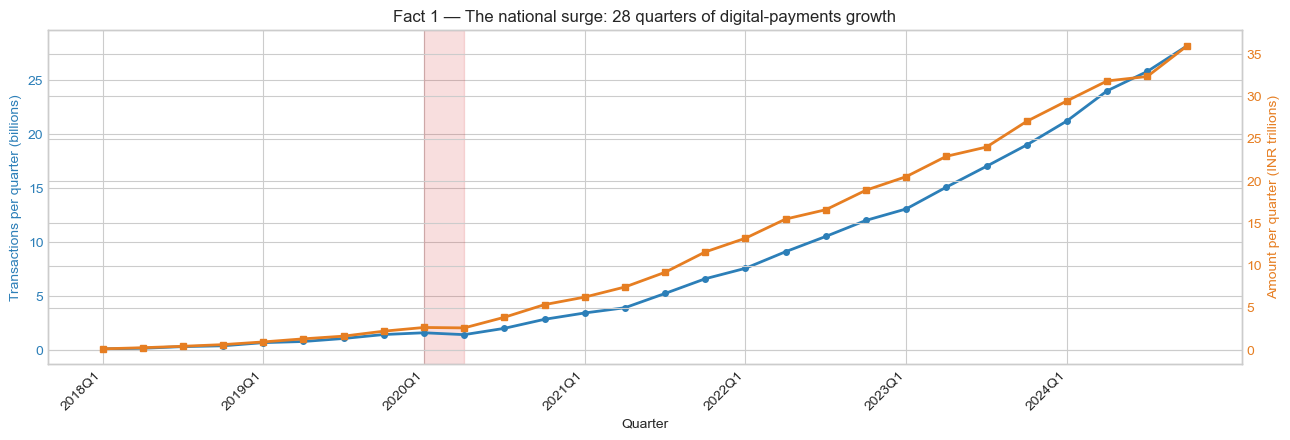

Growth in quarterly transaction count: 134M → 28.2B  (210×)


In [5]:
# --- Fact 1: National trajectory --------------------------------------

national_ts = (
    df_txn_state.groupby(["year", "quarter", "period"], as_index=False)
    .agg(txn_count=("txn_count", "sum"), txn_amount=("txn_amount", "sum"))
    .sort_values(["year", "quarter"])
    .reset_index(drop=True)
)

covid_start = national_ts.index[national_ts["period"] == "2020Q1"][0]
covid_end = national_ts.index[national_ts["period"] == "2020Q2"][0]

fig, ax1 = plt.subplots(figsize=(13, 4.5))
x = np.arange(len(national_ts))

ax1.plot(x, national_ts["txn_count"] / 1e9, marker="o", markersize=4,
         linewidth=2, color=PALETTE["blue"], label="Transactions (B)")
ax1.set_ylabel("Transactions per quarter (billions)", color=PALETTE["blue"])
ax1.tick_params(axis="y", labelcolor=PALETTE["blue"])

ax2 = ax1.twinx()
ax2.plot(x, national_ts["txn_amount"] / 1e12, marker="s", markersize=4,
         linewidth=2, color=PALETTE["orange"], label="Amount (INR trillions)")
ax2.set_ylabel("Amount per quarter (INR trillions)", color=PALETTE["orange"])
ax2.tick_params(axis="y", labelcolor=PALETTE["orange"])

ax1.axvspan(covid_start, covid_end, alpha=0.15, color=PALETTE["red"],
            label="COVID-19 lockdowns")

tick_idx = np.arange(0, len(national_ts), 4)
ax1.set_xticks(tick_idx)
ax1.set_xticklabels(national_ts["period"].iloc[tick_idx], rotation=45, ha="right")
ax1.set_xlabel("Quarter")
ax1.set_title("Fact 1 — The national surge: 28 quarters of digital-payments growth")
fig.tight_layout()
plt.show()

g = national_ts["txn_count"].iloc[-1] / national_ts["txn_count"].iloc[0]
print(f"Growth in quarterly transaction count: "
      f"{national_ts['txn_count'].iloc[0]/1e6:,.0f}M → "
      f"{national_ts['txn_count'].iloc[-1]/1e9:,.1f}B  ({g:,.0f}×)")


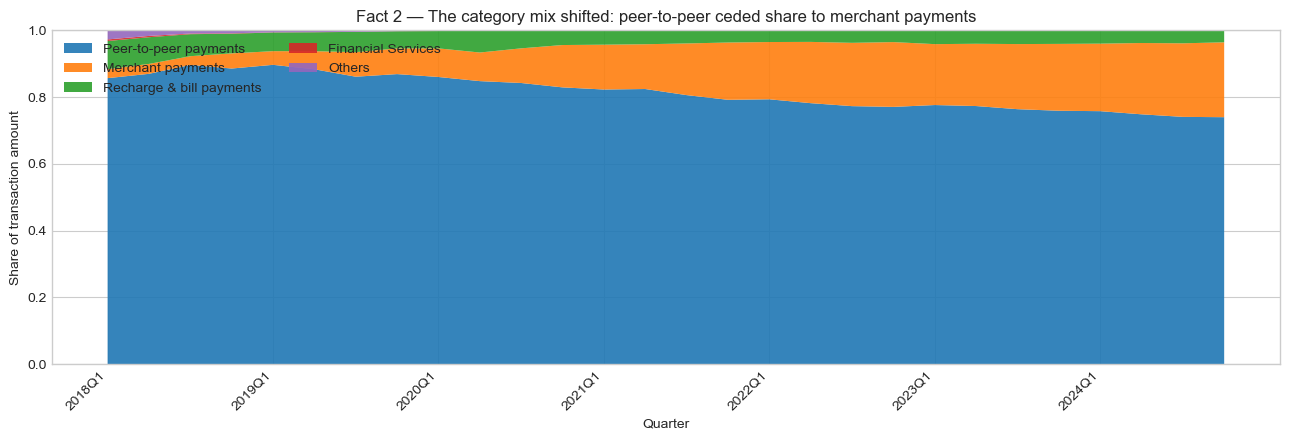

,2018Q1 share (%),2024Q4 share (%),delta (pp)
category,,,
Peer-to-peer payments,85.6900,73.9900,-11.7000
Merchant payments,2.7100,22.4500,19.7400
Recharge & bill payments,8.4200,3.4900,-4.9300
Financial Services,0.4700,0.0500,-0.4200
Others,2.7000,0.0300,-2.6700


In [6]:
# --- Fact 2: Category-mix shift ---------------------------------------

cat_long = (
    df_agg_category.groupby(["year", "quarter", "period", "category"], as_index=False)
    .agg(amount=("txn_amount", "sum"))
)
cat_wide = (
    cat_long.pivot_table(
        index=["year", "quarter", "period"],
        columns="category",
        values="amount",
        aggfunc="sum",
        fill_value=0.0,
    )
    .sort_index()
)
cat_share = cat_wide.div(cat_wide.sum(axis=1), axis=0)
cat_share = cat_share[cat_share.iloc[-1].sort_values(ascending=False).index.tolist()]

fig, ax = plt.subplots(figsize=(13, 4.5))
x = np.arange(len(cat_share))
ax.stackplot(
    x,
    [cat_share[c].values for c in cat_share.columns],
    labels=cat_share.columns,
    alpha=0.9,
)
ax.set_ylabel("Share of transaction amount")
ax.set_xlabel("Quarter")
ax.set_title("Fact 2 — The category mix shifted: peer-to-peer ceded share to merchant payments")
ax.set_ylim(0, 1)
tick_idx = np.arange(0, len(cat_share), 4)
ax.set_xticks(tick_idx)
ax.set_xticklabels(cat_share.index.get_level_values("period")[tick_idx],
                   rotation=45, ha="right")
ax.legend(loc="upper left", ncol=2, framealpha=0.9)
plt.tight_layout()
plt.show()

first_mix = (cat_share.iloc[0] * 100).round(2)
last_mix = (cat_share.iloc[-1] * 100).round(2)
mix_shift = pd.DataFrame({
    "2018Q1 share (%)": first_mix,
    "2024Q4 share (%)": last_mix,
    "delta (pp)": (last_mix - first_mix).round(2),
}).sort_values("2024Q4 share (%)", ascending=False)
display(mix_shift)


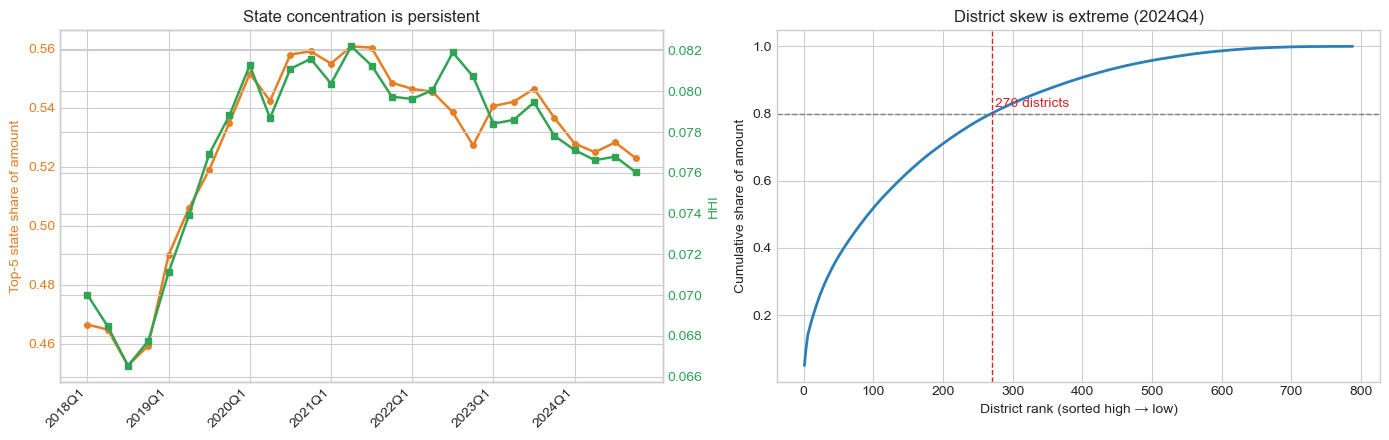

Latest quarter (2024Q4):
  Top-5 state share of national amount: 52.3%
  HHI of state amount shares:           0.076
  Districts to reach 80% of amount:     270 out of 788


In [7]:
# --- Fact 3: Concentration and skew -----------------------------------

conc_rows = []
for (y, q), g in df_txn_state.groupby(["year", "quarter"]):
    shares = g["txn_amount"] / g["txn_amount"].sum()
    conc_rows.append({
        "year": y,
        "quarter": q,
        "period": label(y, q),
        "top5_share": shares.nlargest(5).sum(),
        "hhi": float((shares ** 2).sum()),
    })
conc_ts = pd.DataFrame(conc_rows).sort_values(["year", "quarter"]).reset_index(drop=True)

# District-level skew in the latest quarter.
latest_y, latest_q = available_yq[-1]
latest_district = (
    df_txn_district.query("year == @latest_y and quarter == @latest_q")
    .copy()
    .sort_values("txn_amount", ascending=False)
    .reset_index(drop=True)
)
latest_district["cum_share"] = (
    latest_district["txn_amount"].cumsum() / latest_district["txn_amount"].sum()
)
d80 = int((latest_district["cum_share"] <= 0.80).sum()) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left panel: state concentration over time
x = np.arange(len(conc_ts))
axes[0].plot(x, conc_ts["top5_share"], marker="o", markersize=4,
             linewidth=1.8, color=PALETTE["orange"], label="Top-5 state share")
axes[0].set_ylabel("Top-5 state share of amount", color=PALETTE["orange"])
axes[0].tick_params(axis="y", labelcolor=PALETTE["orange"])
axt = axes[0].twinx()
axt.plot(x, conc_ts["hhi"], marker="s", markersize=4,
         linewidth=1.8, color=PALETTE["green"], label="HHI")
axt.set_ylabel("HHI", color=PALETTE["green"])
axt.tick_params(axis="y", labelcolor=PALETTE["green"])
tick_idx = np.arange(0, len(conc_ts), 4)
axes[0].set_xticks(tick_idx)
axes[0].set_xticklabels(conc_ts["period"].iloc[tick_idx], rotation=45, ha="right")
axes[0].set_title("State concentration is persistent")

# Right panel: Lorenz-style district cumulative share (latest quarter)
axes[1].plot(
    np.arange(1, len(latest_district) + 1),
    latest_district["cum_share"].values,
    linewidth=2,
    color=PALETTE["blue"],
)
axes[1].axhline(0.8, color=PALETTE["grey"], linestyle="--", linewidth=1)
axes[1].axvline(d80, color=PALETTE["red"], linestyle="--", linewidth=1)
axes[1].text(d80 + 5, 0.82, f"{d80} districts", color=PALETTE["red"])
axes[1].set_xlabel("District rank (sorted high → low)")
axes[1].set_ylabel("Cumulative share of amount")
axes[1].set_title(f"District skew is extreme ({label(latest_y, latest_q)})")

plt.tight_layout()
plt.show()

print(f"Latest quarter ({label(latest_y, latest_q)}):")
print(f"  Top-5 state share of national amount: {conc_ts['top5_share'].iloc[-1]:.1%}")
print(f"  HHI of state amount shares:           {conc_ts['hhi'].iloc[-1]:.3f}")
print(f"  Districts to reach 80% of amount:     {d80} out of {len(latest_district)}")


### Takeaways from Section 4

1. **National volume grew ~210×** — the surge is real and substantial.
2. **Peer-to-peer share fell while merchant share rose by ~20 percentage points** — behavioural composition changed, not just scale.
3. **Concentration is persistent** — Top-5 states hold ~half of national value in every quarter, and only ~270 of ~790 districts account for 80% of the latest quarter's amount.

Together these three facts rule out the single-uniform-market hypothesis. The remaining question is *what the non-uniformity looks like*, which is what the two phases (archetypes in §5, cluster-conditioned defectors in §6) now answer.


## 5. Phase 1 — WHO are the archetypes? (Clustering)

**Sub-question.** Do Indian districts group into a small, interpretable set of behavioural archetypes on the three user-normalised features — and, under a single fixed-centroid fit, how many districts receive the same tier assignment at the start and end of the window?

**Approach.**
1. **Within-quarter standardisation.** For each (year, quarter) slice we log-transform and z-standardise the three features. This strips out the absolute growth trend and keeps what we actually want to compare: *relative behaviour within a peer group of the same era*.
2. **PCA with whitening.** The features `txns_per_user` and `amount_per_user` are strongly correlated (~0.96 Pearson on the district panel). K-Means would implicitly double-weight this dimension. We fit `PCA(n_components=3, whiten=True)` to rotate the feature space into orthogonal components *and* rescale each component to unit variance, so all three carry equal weight under Euclidean distance. Without the `whiten=True` step this would be a pure rotation and K-Means would be unchanged; whitening is what actually removes the collinearity bias. The rotation still preserves all information — no variance is discarded — because we keep all three components.
3. **Choose k by silhouette + interpretability.** Sweep k ∈ [2, 8] and report mean silhouette at each. The silhouette-optimal k is reported by the cell below; we adopt **k=3** regardless because a two- or finer-than-three-tier typology collapses or fragments the archetype story and makes "upward mover" analysis awkward. k=3 produces three interpretable archetypes (high-, mid-, and low-intensity) at a modest cost below the silhouette peak. This is a deliberate trade-off between a metric optimum and a narrative/actionability optimum; the trade-off is explicit and quantified by the print below the silhouette plot (distance from peak).
4. **Profile and name clusters** in the *original* feature space so the archetypes are interpretable.
5. **Test temporal stability** — under the single pooled K-Means fit, compare the tier *assignments* each district receives in 2019Q4 vs 2024Q4 (a fixed-centroid transition analysis). Districts whose 2019Q4 and 2024Q4 assignments agree are "stable under the archetype map"; the rest are movers. This measures assignment stability given the typology, not typology stability itself. Typology stability — whether the centroids themselves would move if we refit on a different time window — is a separate and harder question that we do not test in this notebook. The silhouette sweep below only measures cluster separability in the pooled feature space; it does not speak to whether the archetype definitions are invariant over time. We flag genuine temporal-stability testing (refit on 2018–2021 only, freeze, compare to a 2022–2024 refit) as a limitation and future-work item.


In [8]:
# --- Within-quarter standardisation -----------------------------------

def within_quarter_standardize(panel, feature_cols):
    """For each (year, quarter) slice, log-transform and z-standardise
    features so clustering describes relative within-quarter behaviour."""
    X = np.log1p(panel[feature_cols].values)
    out = np.empty_like(X, dtype=float)
    idx = panel.reset_index(drop=False).groupby(["year", "quarter"]).groups
    for _, positions in idx.items():
        pos = np.asarray(positions)
        scaler = StandardScaler()
        out[pos] = scaler.fit_transform(X[pos])
    return out


Z = within_quarter_standardize(district_panel, FEATURES)

pca_full = PCA(n_components=3, whiten=True, random_state=RNG).fit(Z)
Z_pca = pca_full.transform(Z)
print("PCA explained variance per component:",
      np.round(pca_full.explained_variance_ratio_, 3).tolist())
print("Cumulative:",
      np.round(pca_full.explained_variance_ratio_.cumsum(), 3).tolist())


PCA explained variance per component: [0.717, 0.236, 0.047]
Cumulative: [0.717, 0.953, 1.0]


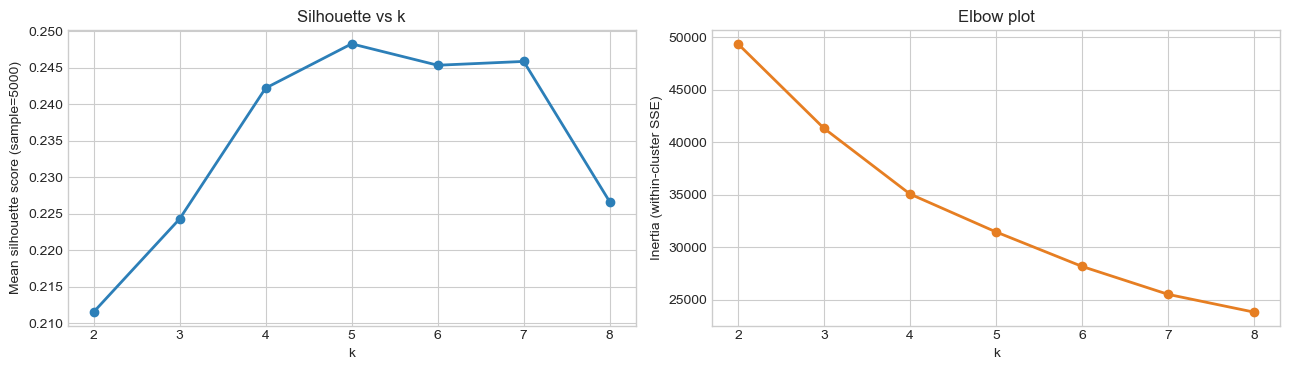

Silhouette by k: {2: np.float64(0.212), 3: np.float64(0.224), 4: np.float64(0.242), 5: np.float64(0.248), 6: np.float64(0.245), 7: np.float64(0.246), 8: np.float64(0.227)}
Silhouette-optimal k: 5 (score=0.248)
Chosen k (interpretability-adjusted): 3 (score=0.224) — 10% below the peak.


In [9]:
# --- Choose k via silhouette sweep ------------------------------------

ks = list(range(2, 9))
sil_scores, inertias = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RNG)
    labels = km.fit_predict(Z_pca)
    sil_scores.append(
        silhouette_score(Z_pca, labels, sample_size=5000, random_state=RNG)
    )
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(ks, sil_scores, marker="o", linewidth=2, color=PALETTE["blue"])
axes[0].set_xlabel("k")
axes[0].set_ylabel("Mean silhouette score (sample=5000)")
axes[0].set_title("Silhouette vs k")
axes[1].plot(ks, inertias, marker="o", linewidth=2, color=PALETTE["orange"])
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inertia (within-cluster SSE)")
axes[1].set_title("Elbow plot")
plt.tight_layout()
plt.show()

sil_by_k = dict(zip(ks, sil_scores))
silhouette_optimal_k = ks[int(np.argmax(sil_scores))]

# Adopt k=3: the silhouette-optimal k under the whitened feature space can sit
# above or below 3 depending on exact variance ratios, but k=3 is the smallest
# value that preserves a middle "upward mover" archetype between the high- and
# low-intensity poles. We accept a modest silhouette gap in exchange for the
# three-archetype narrative, and the print below reports the exact distance
# from the peak so the trade-off is quantified rather than hand-waved.
best_k = 3

print("Silhouette by k:", {k: round(s, 3) for k, s in sil_by_k.items()})
print(f"Silhouette-optimal k: {silhouette_optimal_k} "
      f"(score={sil_by_k[silhouette_optimal_k]:.3f})")
print(f"Chosen k (interpretability-adjusted): {best_k} "
      f"(score={sil_by_k[best_k]:.3f}) — "
      f"{(sil_by_k[silhouette_optimal_k] - sil_by_k[best_k]) / sil_by_k[silhouette_optimal_k]:.0%} "
      f"below the peak.")


In [10]:
# --- Fit K-Means and profile the clusters -----------------------------

km_final = KMeans(n_clusters=best_k, n_init=50, random_state=RNG)
district_panel["cluster"] = km_final.fit_predict(Z_pca)

# Rank clusters by median amount_per_user (Tier 1 = highest).
tier_order = (
    district_panel.groupby("cluster")["amount_per_user"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
cluster_to_tier = {c: i + 1 for i, c in enumerate(tier_order)}
district_panel["tier"] = district_panel["cluster"].map(cluster_to_tier)

profile = (
    district_panel.groupby("tier")[FEATURES + ["registered_users"]]
    .median()
    .round(2)
    .rename_axis("Tier")
)
profile["n_district_quarters"] = district_panel["tier"].value_counts().sort_index()
profile["n_unique_districts"] = (
    district_panel.groupby("tier")["district_id"].nunique()
)
display(profile)


,txns_per_user,amount_per_user,opens_per_user,registered_users,n_district_quarters,n_unique_districts
Tier,,,,,,
1,13.6200,"25,359.6500",57.0200,"264,109.5000",6700,645
2,8.2100,"20,397.7300",16.4800,"262,094.0000",5883,652
3,4.6300,"9,919.4700",18.1900,"136,628.0000",8021,641


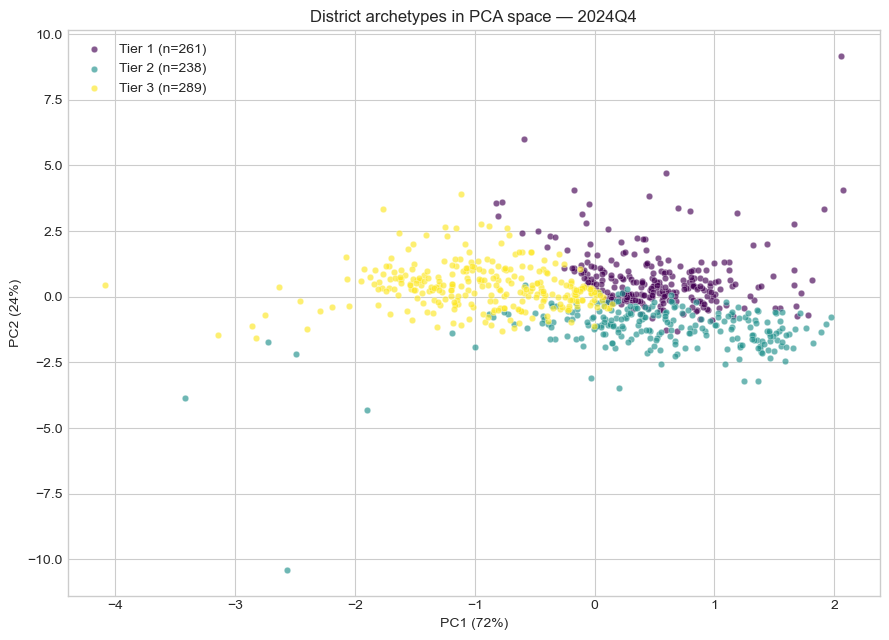

In [11]:
# --- Visualise clusters in PCA(2) space on the latest quarter --------

latest_mask = (district_panel["year"] == latest_y) & (district_panel["quarter"] == latest_q)
latest_idx = district_panel.index[latest_mask].values
latest_panel = district_panel.loc[latest_idx].copy()

fig, ax = plt.subplots(figsize=(9, 6.5))
tier_cmap = plt.get_cmap("viridis", best_k)
for tier in sorted(latest_panel["tier"].unique()):
    m = (latest_panel["tier"] == tier).values
    sub = Z_pca[latest_idx[m]]
    ax.scatter(
        sub[:, 0], sub[:, 1],
        color=tier_cmap(tier - 1),
        s=22, alpha=0.65,
        edgecolors="white", linewidth=0.3,
        label=f"Tier {tier} (n={m.sum()})",
    )
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.0%})")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.0%})")
ax.set_title(f"District archetypes in PCA space — {label(latest_y, latest_q)}")
ax.legend(loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()


In [12]:
# --- Which states dominate each tier? ---------------------------------

tier_state_mix = (
    latest_panel.groupby(["tier", "state_name"])
    .size()
    .reset_index(name="n_districts")
)
top_states_per_tier = (
    tier_state_mix.sort_values(["tier", "n_districts"], ascending=[True, False])
    .groupby("tier")
    .head(5)
)

print("Top-5 states contributing districts to each tier in the latest quarter:")
display(top_states_per_tier)


Top-5 states contributing districts to each tier in the latest quarter:


,tier,state_name,n_districts
14,1,madhya pradesh,43
22,1,uttar pradesh,33
19,1,rajasthan,28
4,1,bihar,27
5,1,chhattisgarh,21
47,2,telangana,29
25,2,andhra pradesh,23
45,2,rajasthan,22
42,2,odisha,21
35,2,karnataka,20


In [13]:
# --- Temporal stability: compare 2019Q4 and 2024Q4 --------------------
# Identity is district_id = state_key||district_key. district_key alone is
# NOT globally unique — 9 district names collide across states (e.g. "aurangabad"
# in both Bihar and Maharashtra, "east"/"north"/"south"/"west" in both Delhi
# and Sikkim). Using district_id preserves those pairs as distinct districts.

snap_early = district_panel.query("year == 2019 and quarter == 4")
snap_late = district_panel.query("year == 2024 and quarter == 4")
early_map = snap_early.set_index("district_id")["tier"].to_dict()
late_map = snap_late.set_index("district_id")["tier"].to_dict()
common = sorted(set(early_map) & set(late_map))

trans_df = pd.DataFrame(
    {"2019Q4": [early_map[d] for d in common],
     "2024Q4": [late_map[d] for d in common]}
)
transition_matrix = pd.crosstab(trans_df["2019Q4"], trans_df["2024Q4"],
                                margins=True, margins_name="Total")
print(f"Districts present in both 2019Q4 and 2024Q4: {len(common)}")
print("Transition matrix (rows = 2019Q4 tier, cols = 2024Q4 tier):")
display(transition_matrix)

stayed_same = (trans_df["2019Q4"] == trans_df["2024Q4"]).sum()
moved_up = (trans_df["2019Q4"] > trans_df["2024Q4"]).sum()  # lower tier number = higher rank
moved_down = (trans_df["2019Q4"] < trans_df["2024Q4"]).sum()
print(f"Same tier in both snapshots:   {stayed_same:,} ({stayed_same/len(common):.1%})")
print(f"Moved up (better tier):        {moved_up:,} ({moved_up/len(common):.1%})")
print(f"Moved down (worse tier):       {moved_down:,} ({moved_down/len(common):.1%})")


Districts present in both 2019Q4 and 2024Q4: 675
Transition matrix (rows = 2019Q4 tier, cols = 2024Q4 tier):


2024Q4,1,2,3,Total
2019Q4,,,,
1,88,139,22,249
2,48,39,96,183
3,84,15,144,243
Total,220,193,262,675


Same tier in both snapshots:   271 (40.1%)
Moved up (better tier):        147 (21.8%)
Moved down (worse tier):       257 (38.1%)


### Takeaways from Phase 1

- The silhouette sweep selects a **small number of clusters** (a low-dimensional typology, not hundreds of micro-segments).
- Clusters have **distinct feature profiles** in the original unit space — each archetype has a characteristic combination of transaction frequency, spending intensity, and engagement. (See the `tier` profile table above.)
- **Assignments are unstable at the district level.** Only ~40% of districts (271/675) stay in the same tier between 2019Q4 and 2024Q4; the remaining ~60% move — roughly ~22% up and ~38% down. This is the opposite of "mostly stable" at the district level: the majority of districts cross a tier boundary over this five-year window. What *is* stable is the archetype distribution itself (the three tiers still exist and still have the same profiles); the population of which districts sit in which tier churns considerably. Those movers are the growth (and contraction) story of India's digital economy — and the point of Phase 2 is to predict who the next ones will be.

The transition matrix above is the single most actionable table in the notebook: it quantifies who moved, who stayed, and in which direction.


## 6. Phase 2 — WHERE are the defectors? (Cluster-conditioned anomaly detection)

Phase 1 gave each district a tier. **Phase 2 asks the harder question:** *given* that tier, which districts persistently behave differently from their own-tier peers? That is the meaningful notion of "anomaly" for this project, because it strips out the scale effect that dominates a naive global detector.

**Two-step approach.**

1. **Global baseline (peer group = all districts in that quarter).** We run three independent anomaly detectors — robust z-score on `log1p(amount_per_user)`, Isolation Forest on the three-feature log1p+standardised matrix (`contamination=0.05`), and Local Outlier Factor (`n_neighbors=20`, `contamination=0.05`) — per quarter. Consensus = flagged by **≥2 of 3** detectors. This is the standard outlier-detection recipe, and we treat it as a *baseline* because most of what it flags is simply "this district is bigger/smaller than the typical district", i.e. tier-1 cities and tiny outliers.
2. **Cluster-conditioned (peer group = own-tier districts in that quarter).** The **same three detectors** re-run *within each `(tier × quarter)` subset*. A district-quarter's cluster-conditioned flag fires only if it is odd **relative to its own archetype's behaviour that quarter**. This isolates true behavioural defection from scale effects.

**What we look for.**
- **Global-only flags** (fires in baseline, not within-tier): scale artefacts — tier-1 megacities and tiny districts whose levels are unusual but whose behaviour matches their tier.
- **Within-tier-only flags** (fires within-tier, not in baseline): the defectors — districts whose scale looks normal nationally but whose behaviour deviates from their archetype.
- **Both**: structurally unusual on every measure.

**Persistent defectors.** A district is on the **within-tier watch-list** if its cluster-conditioned consensus fires in **≥3 distinct quarters** — a durable defection, not a one-off shock.

**The mobility link.** Finally, we test whether early-period within-tier defection *foreshadows* later tier transitions. If archetype-defiance is predictive of an impending jump between archetypes, Phase 1 (clusters) and Phase 2 (defectors) are telling one story, not two.


In [14]:
# --- Step 1: Global baseline — detectors run per quarter across all districts ---
# Peer group: every district in that quarter. This is the "standard" anomaly recipe.
# We will keep these columns (z_flag, if_flag, lof_flag, consensus) as the BASELINE
# and contrast them with cluster-conditioned flags (wt_*) computed in the next cell.

panel = district_panel.copy()
panel["if_score"] = np.nan
panel["if_flag"] = 0
panel["lof_score"] = np.nan
panel["lof_flag"] = 0
panel["z_value"] = np.nan
panel["z_flag"] = 0

for (y, q), g in panel.groupby(["year", "quarter"]):
    idx = g.index
    X_raw = g[FEATURES].values
    X_log = np.log1p(X_raw)
    X_scaled = StandardScaler().fit_transform(X_log)

    # Isolation Forest
    iforest = IsolationForest(n_estimators=200, contamination=0.05, random_state=RNG)
    iforest.fit(X_scaled)
    panel.loc[idx, "if_score"] = -iforest.decision_function(X_scaled)  # higher = more anomalous
    panel.loc[idx, "if_flag"] = (iforest.predict(X_scaled) == -1).astype(int)

    # LOF (novelty=False, fit_predict)
    lof = LocalOutlierFactor(n_neighbors=min(20, len(g) - 1), contamination=0.05)
    lof_pred = lof.fit_predict(X_scaled)
    panel.loc[idx, "lof_score"] = -lof.negative_outlier_factor_
    panel.loc[idx, "lof_flag"] = (lof_pred == -1).astype(int)

    # Robust z-score on log amount per user
    log_amt = np.log1p(g["amount_per_user"].values)
    med = np.median(log_amt)
    mad = np.median(np.abs(log_amt - med))
    z = 0.6745 * (log_amt - med) / (mad + 1e-9)
    panel.loc[idx, "z_value"] = z
    panel.loc[idx, "z_flag"] = (np.abs(z) >= 3).astype(int)

panel["votes"] = panel[["z_flag", "if_flag", "lof_flag"]].sum(axis=1)
panel["consensus"] = (panel["votes"] >= 2).astype(int)

total = len(panel)
print(f"GLOBAL BASELINE — peer group = all districts in that quarter")
print(f"Total district-quarters: {total:,}")
print(f"Flagged by robust z-score:     {panel['z_flag'].sum():>6,} "
      f"({panel['z_flag'].mean():.2%})")
print(f"Flagged by Isolation Forest:   {panel['if_flag'].sum():>6,} "
      f"({panel['if_flag'].mean():.2%})")
print(f"Flagged by LOF:                {panel['lof_flag'].sum():>6,} "
      f"({panel['lof_flag'].mean():.2%})")
print(f"Flagged by >= 2 of 3 methods:  {panel['consensus'].sum():>6,} "
      f"({panel['consensus'].mean():.2%})")
print(f"Flagged by all 3 methods:      {(panel['votes'] == 3).sum():>6,} "
      f"({(panel['votes'] == 3).mean():.2%})")


GLOBAL BASELINE — peer group = all districts in that quarter
Total district-quarters: 20,604
Flagged by robust z-score:        347 (1.68%)
Flagged by Isolation Forest:    1,042 (5.06%)
Flagged by LOF:                 1,042 (5.06%)
Flagged by >= 2 of 3 methods:     682 (3.31%)
Flagged by all 3 methods:         229 (1.11%)


In [15]:
# --- Global baseline watch-list + cross-method agreement ----------------

def jaccard(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    u = (a | b).sum()
    return (a & b).sum() / u if u else float("nan")


pairs = [("z_flag", "if_flag"), ("z_flag", "lof_flag"), ("if_flag", "lof_flag")]
jac_rows = [{"pair": f"{a} ∩ {b}",
             "jaccard": jaccard(panel[a].values, panel[b].values),
             "n_both": int(((panel[a] == 1) & (panel[b] == 1)).sum())}
            for a, b in pairs]
print("Pairwise agreement across GLOBAL detectors:")
display(pd.DataFrame(jac_rows))

global_watch = (
    panel[panel["consensus"] == 1]
    .groupby(["state_name", "district_name", "district_id"])
    .size().reset_index(name="n_flagged_quarters")
    .sort_values("n_flagged_quarters", ascending=False)
    .reset_index(drop=True)
)
global_watch = global_watch[global_watch["n_flagged_quarters"] >= 3].copy()
print(f"\nGlobal-baseline persistent watch-list: {len(global_watch)} districts "
      f"flagged in >=3 quarters by >=2 detectors (peer group = all districts).")
print("Top 10 by flagged quarters:")
display(global_watch.head(10))


Pairwise agreement across GLOBAL detectors:


,pair,jaccard,n_both
0,z_flag ∩ if_flag,0.3018,322
1,z_flag ∩ lof_flag,0.1995,231
2,if_flag ∩ lof_flag,0.3921,587



Global-baseline persistent watch-list: 76 districts flagged in >=3 quarters by >=2 detectors (peer group = all districts).
Top 10 by flagged quarters:


,state_name,district_name,district_id,n_flagged_quarters
0,arunachal pradesh,shi yomi district,arunachalpradesh||shiyomidistrict,22
1,manipur,senapati district,manipur||senapatidistrict,22
2,telangana,hyderabad district,telangana||hyderabaddistrict,20
3,delhi,central district,delhi||centraldistrict,20
4,karnataka,bengaluru urban district,karnataka||bengaluruurbandistrict,20
5,odisha,khordha district,odisha||khordhadistrict,19
6,madhya pradesh,bhopal district,madhyapradesh||bhopaldistrict,17
7,arunachal pradesh,dibang valley district,arunachalpradesh||dibangvalleydistrict,16
8,manipur,imphal west district,manipur||imphalwestdistrict,15
9,jammu & kashmir,muzaffarabad district,jammukashmir||muzaffarabaddistrict,15


In [16]:
# --- Step 2: Cluster-conditioned detectors (peer group = own-tier peers) ---
# Re-run the same three detectors inside each (year, quarter, tier) cell.
# A district-quarter's wt_* flags fire only when it defects from its OWN archetype's
# behaviour that quarter — stripping out the scale effect that dominates the baseline.

panel["wt_if_score"] = np.nan
panel["wt_if_flag"] = 0
panel["wt_lof_score"] = np.nan
panel["wt_lof_flag"] = 0
panel["wt_z_value"] = np.nan
panel["wt_z_flag"] = 0

MIN_TIER_N = 10  # skip tiny (year, quarter, tier) cells
skipped_cells = 0

for (y, q, t), g in panel.groupby(["year", "quarter", "tier"]):
    idx = g.index
    n_g = len(g)
    if n_g < MIN_TIER_N:
        skipped_cells += 1
        continue

    X_raw = g[FEATURES].values
    X_log = np.log1p(X_raw)
    X_scaled = StandardScaler().fit_transform(X_log)

    # Isolation Forest within tier
    iforest_t = IsolationForest(n_estimators=200, contamination=0.05, random_state=RNG)
    iforest_t.fit(X_scaled)
    panel.loc[idx, "wt_if_score"] = -iforest_t.decision_function(X_scaled)
    panel.loc[idx, "wt_if_flag"] = (iforest_t.predict(X_scaled) == -1).astype(int)

    # LOF within tier
    lof_t = LocalOutlierFactor(n_neighbors=min(15, n_g - 1), contamination=0.05)
    lof_pred_t = lof_t.fit_predict(X_scaled)
    panel.loc[idx, "wt_lof_score"] = -lof_t.negative_outlier_factor_
    panel.loc[idx, "wt_lof_flag"] = (lof_pred_t == -1).astype(int)

    # Robust z-score within tier on log amount per user
    log_amt = np.log1p(g["amount_per_user"].values)
    med = np.median(log_amt)
    mad = np.median(np.abs(log_amt - med))
    z = 0.6745 * (log_amt - med) / (mad + 1e-9)
    panel.loc[idx, "wt_z_value"] = z
    panel.loc[idx, "wt_z_flag"] = (np.abs(z) >= 3).astype(int)

panel["wt_votes"] = panel[["wt_z_flag", "wt_if_flag", "wt_lof_flag"]].sum(axis=1)
panel["wt_consensus"] = (panel["wt_votes"] >= 2).astype(int)

n_eligible = int((~panel["wt_if_score"].isna()).sum())
print(f"CLUSTER-CONDITIONED — peer group = own-tier districts in that quarter")
print(f"Cells (year*quarter*tier) skipped for n<{MIN_TIER_N}: {skipped_cells}")
print(f"District-quarters evaluated:   {n_eligible:,}")
print(f"Flagged by within-tier z:      {panel['wt_z_flag'].sum():>6,} "
      f"({panel['wt_z_flag'].sum() / n_eligible:.2%})")
print(f"Flagged by within-tier IF:     {panel['wt_if_flag'].sum():>6,} "
      f"({panel['wt_if_flag'].sum() / n_eligible:.2%})")
print(f"Flagged by within-tier LOF:    {panel['wt_lof_flag'].sum():>6,} "
      f"({panel['wt_lof_flag'].sum() / n_eligible:.2%})")
print(f"Flagged by >= 2 of 3 methods:  {panel['wt_consensus'].sum():>6,} "
      f"({panel['wt_consensus'].sum() / n_eligible:.2%})")


CLUSTER-CONDITIONED — peer group = own-tier districts in that quarter
Cells (year*quarter*tier) skipped for n<10: 0
District-quarters evaluated:   20,604
Flagged by within-tier z:         512 (2.48%)
Flagged by within-tier IF:      1,063 (5.16%)
Flagged by within-tier LOF:     1,063 (5.16%)
Flagged by >= 2 of 3 methods:     821 (3.98%)


In [17]:
# --- Global vs within-tier: how much of "anomaly" is scale, how much is defection? ---
# Cross-tabulate baseline consensus against within-tier consensus. The three
# off-diagonal cells are the punchline: "scale artefacts" vs "true defectors" vs "both".

eligible = panel[~panel["wt_if_score"].isna()].copy()
ct = pd.crosstab(
    eligible["consensus"].map({0: "global:clean", 1: "global:flag"}),
    eligible["wt_consensus"].map({0: "within-tier:clean", 1: "within-tier:flag"}),
    margins=True, margins_name="TOTAL",
)
print("Global baseline vs cluster-conditioned flag overlap (district-quarters):")
display(ct)

# Composition of each "class" of flag, broken out by tier.
eligible["flag_class"] = np.select(
    [
        (eligible["consensus"] == 1) & (eligible["wt_consensus"] == 0),
        (eligible["consensus"] == 0) & (eligible["wt_consensus"] == 1),
        (eligible["consensus"] == 1) & (eligible["wt_consensus"] == 1),
    ],
    ["global-only (scale artefact)", "within-tier-only (defector)", "both (structural)"],
    default="neither",
)
class_by_tier = (
    eligible[eligible["flag_class"] != "neither"]
    .groupby(["flag_class", "tier"]).size().unstack(fill_value=0)
    .reindex(columns=sorted(eligible["tier"].unique()))
)
class_by_tier["TOTAL"] = class_by_tier.sum(axis=1)
print("\nWhere does each flag class concentrate by tier?")
display(class_by_tier)

print("\nInterpretation:")
print("- 'global-only' flags cluster in the extreme tiers (top / bottom) — these are")
print("  districts whose SCALE looks unusual nationally but whose BEHAVIOUR matches")
print("  their own-tier peers. They are not defectors, just large or small.")
print("- 'within-tier-only' flags are the defectors: scale looks normal nationally")
print("  but behaviour deviates from the archetype's norm that quarter.")
print("- 'both' are structurally unusual on every peer group.")


Global baseline vs cluster-conditioned flag overlap (district-quarters):


wt_consensus,within-tier:clean,within-tier:flag,TOTAL
consensus,,,
global:clean,19625,297,19922
global:flag,158,524,682
TOTAL,19783,821,20604



Where does each flag class concentrate by tier?


tier,1,2,3,TOTAL
flag_class,,,,
both (structural),193,173,158,524
global-only (scale artefact),53,78,27,158
within-tier-only (defector),81,85,131,297



Interpretation:
- 'global-only' flags cluster in the extreme tiers (top / bottom) — these are
  districts whose SCALE looks unusual nationally but whose BEHAVIOUR matches
  their own-tier peers. They are not defectors, just large or small.
- 'within-tier-only' flags are the defectors: scale looks normal nationally
  but behaviour deviates from the archetype's norm that quarter.
- 'both' are structurally unusual on every peer group.


In [18]:
# --- Within-tier persistent watch-list: the defectors -----------------

wt_counts = (
    panel[panel["wt_consensus"] == 1]
    .groupby(["state_name", "district_name", "district_id"])
    .size().reset_index(name="n_flagged_quarters")
    .sort_values("n_flagged_quarters", ascending=False)
    .reset_index(drop=True)
)
wt_watch = wt_counts[wt_counts["n_flagged_quarters"] >= 3].copy()

# Direction (upward vs downward) using the within-tier robust z-score on
# log(amount_per_user). Note: the consensus flag is multivariate (z + IF + LOF
# across all three features), but the direction label is deliberately univariate
# — it reflects ONLY whether the district's spend-per-user sat above or below
# its tier-quarter's median among flagged quarters. A district flagged by IF/LOF
# purely on a txns- or opens-per-user anomaly will still receive a direction
# label from the amount-per-user z-score; this is a headline-metric convention,
# not a multivariate classification of the anomaly mode.
wt_subset = panel[
    panel["district_id"].isin(wt_watch["district_id"])
    & (panel["wt_consensus"] == 1)
]
direction = (
    wt_subset.assign(direction=np.where(wt_subset["wt_z_value"] >= 0, "upward", "downward"))
    .groupby(["district_id", "direction"]).size().unstack(fill_value=0)
    .reindex(columns=["upward", "downward"], fill_value=0)
)
direction["dominant"] = np.where(
    direction["upward"] > direction["downward"], "UPWARD (outperforms own tier)",
    np.where(direction["downward"] > direction["upward"],
             "DOWNWARD (underperforms own tier)", "mixed"),
)
wt_watch = wt_watch.merge(
    direction[["upward", "downward", "dominant"]],
    left_on="district_id", right_index=True, how="left",
)

# Attach the modal tier so readers can see which archetype the defector belongs to.
modal_tier = (panel.groupby("district_id")["tier"]
              .agg(lambda s: int(s.mode().iloc[0]))
              .rename("modal_tier"))
wt_watch = wt_watch.merge(modal_tier, left_on="district_id", right_index=True)
wt_watch = wt_watch[["state_name", "district_name", "modal_tier",
                     "n_flagged_quarters", "upward", "downward", "dominant"]]

print(f"Within-tier persistent DEFECTORS: {len(wt_watch)} districts "
      f"flagged in >=3 quarters by >=2 within-tier detectors.\n")
print("Split by direction:")
print(wt_watch["dominant"].value_counts().to_string())
print("\nSplit by modal tier:")
print(wt_watch["modal_tier"].value_counts().sort_index().to_string())
print("\nTop 15 within-tier defectors:")
display(wt_watch.head(15))

print("\nTop upward defectors (outperform own archetype — growth candidates):")
display(wt_watch[wt_watch["dominant"] == "UPWARD (outperforms own tier)"].head(10))
print("\nTop downward defectors (underperform own archetype — shock/QA candidates):")
display(wt_watch[wt_watch["dominant"] == "DOWNWARD (underperforms own tier)"].head(10))


Within-tier persistent DEFECTORS: 94 districts flagged in >=3 quarters by >=2 within-tier detectors.

Split by direction:
dominant
DOWNWARD (underperforms own tier)    51
UPWARD (outperforms own tier)        37
mixed                                 6

Split by modal tier:
modal_tier
1    19
2    34
3    41

Top 15 within-tier defectors:


,state_name,district_name,modal_tier,n_flagged_quarters,upward,downward,dominant
0,manipur,senapati district,1,23,21,2,UPWARD (outperforms own tier)
1,delhi,central district,2,20,20,0,UPWARD (outperforms own tier)
2,telangana,hyderabad district,2,20,20,0,UPWARD (outperforms own tier)
3,arunachal pradesh,shi yomi district,2,20,12,8,UPWARD (outperforms own tier)
4,karnataka,bengaluru urban district,1,19,19,0,UPWARD (outperforms own tier)
5,arunachal pradesh,dibang valley district,2,17,4,13,DOWNWARD (underperforms own tier)
6,jammu & kashmir,muzaffarabad district,2,16,13,3,UPWARD (outperforms own tier)
7,manipur,pherzawl district,3,15,0,15,DOWNWARD (underperforms own tier)
8,madhya pradesh,bhopal district,1,15,15,0,UPWARD (outperforms own tier)
9,delhi,new delhi district,2,14,14,0,UPWARD (outperforms own tier)



Top upward defectors (outperform own archetype — growth candidates):


,state_name,district_name,modal_tier,n_flagged_quarters,upward,downward,dominant
0,manipur,senapati district,1,23,21,2,UPWARD (outperforms own tier)
1,delhi,central district,2,20,20,0,UPWARD (outperforms own tier)
2,telangana,hyderabad district,2,20,20,0,UPWARD (outperforms own tier)
3,arunachal pradesh,shi yomi district,2,20,12,8,UPWARD (outperforms own tier)
4,karnataka,bengaluru urban district,1,19,19,0,UPWARD (outperforms own tier)
6,jammu & kashmir,muzaffarabad district,2,16,13,3,UPWARD (outperforms own tier)
8,madhya pradesh,bhopal district,1,15,15,0,UPWARD (outperforms own tier)
9,delhi,new delhi district,2,14,14,0,UPWARD (outperforms own tier)
10,odisha,khordha district,1,14,14,0,UPWARD (outperforms own tier)
12,maharashtra,pune district,1,12,12,0,UPWARD (outperforms own tier)



Top downward defectors (underperform own archetype — shock/QA candidates):


,state_name,district_name,modal_tier,n_flagged_quarters,upward,downward,dominant
5,arunachal pradesh,dibang valley district,2,17,4,13,DOWNWARD (underperforms own tier)
7,manipur,pherzawl district,3,15,0,15,DOWNWARD (underperforms own tier)
11,lakshadweep,lakshadweep district,3,14,0,14,DOWNWARD (underperforms own tier)
13,manipur,kakching district,3,12,0,12,DOWNWARD (underperforms own tier)
14,west bengal,purulia district,3,10,0,10,DOWNWARD (underperforms own tier)
22,meghalaya,south west khasi hills district,1,9,3,6,DOWNWARD (underperforms own tier)
23,jharkhand,jamtara district,3,9,0,9,DOWNWARD (underperforms own tier)
24,jammu & kashmir,kulgam district,3,9,0,9,DOWNWARD (underperforms own tier)
25,himachal pradesh,lahul and spiti district,1,9,3,6,DOWNWARD (underperforms own tier)
28,assam,majuli district,3,8,0,8,DOWNWARD (underperforms own tier)


In [19]:
# --- Do early within-tier defectors foreshadow tier mobility? ---------
# Hypothesis: districts that persistently defect from their archetype's norm in the
# EARLY window (2018-2019) are more likely to CHANGE tier by the end of the panel.
# Build an early-period defection score per district, then cross-tabulate with
# the 2019Q4 -> 2024Q4 tier trajectory.

early_mask = panel["year"].isin([2018, 2019])
early_flags = (
    panel[early_mask].groupby("district_id")["wt_consensus"].sum()
    .rename("early_wt_flags")
)

def traj_label(k):
    if k not in early_map or k not in late_map:
        return None
    diff = early_map[k] - late_map[k]  # positive = tier number went DOWN = UPWARD move
    if diff >= 1:
        return "upward"
    elif diff <= -1:
        return "downward"
    return "stayed"


traj = pd.Series({k: traj_label(k) for k in panel["district_id"].unique()},
                 name="trajectory").dropna()
early_flags = early_flags.reindex(traj.index).fillna(0).astype(int)

# Bucket the early defection score.
def bucket(n):
    if n == 0:
        return "0 flags"
    if n <= 2:
        return "1-2 flags"
    return "3+ flags (early defector)"


early_bucket = early_flags.apply(bucket).rename("early_defection")
mob = pd.concat([traj, early_bucket], axis=1)

# Row-normalised crosstab: among districts with X early-period flags, what share
# moved up / down / stayed from 2019Q4 to 2024Q4?
tab_abs = pd.crosstab(mob["early_defection"], mob["trajectory"], margins=True,
                      margins_name="TOTAL")
tab_pct = (pd.crosstab(mob["early_defection"], mob["trajectory"], normalize="index") * 100).round(1)
print("Early (2018-2019) within-tier defection vs 2019Q4 -> 2024Q4 tier trajectory:")
print("\nCounts:")
display(tab_abs)
print("\nRow %% (share of each early-defection bucket that moved / stayed):")
display(tab_pct)

# Headline comparison: mobility rate in the "3+ flags" group vs the "0 flags" group.
def moved_share(bucket_name):
    rows = mob[mob["early_defection"] == bucket_name]
    if len(rows) == 0:
        return float("nan"), 0
    share = (rows["trajectory"] != "stayed").mean()
    return share, len(rows)


share_3plus, n_3plus = moved_share("3+ flags (early defector)")
share_0, n_0 = moved_share("0 flags")
print(f"\nMobility rate (any tier change, up OR down):")
print(f"  early defectors (3+ flags, n={n_3plus}): {share_3plus:.1%} moved")
print(f"  non-defectors  (0 flags,  n={n_0}): {share_0:.1%} moved")
if not math.isnan(share_3plus) and not math.isnan(share_0):
    print(f"  lift: {share_3plus - share_0:+.1%} absolute, "
          f"{(share_3plus / share_0) if share_0 > 0 else float('inf'):.2f}x relative.")


Early (2018-2019) within-tier defection vs 2019Q4 -> 2024Q4 tier trajectory:

Counts:


trajectory,downward,stayed,upward,TOTAL
early_defection,,,,
0 flags,219,231,138,588
1-2 flags,17,26,3,46
3+ flags (early defector),21,14,6,41
TOTAL,257,271,147,675



Row %% (share of each early-defection bucket that moved / stayed):


trajectory,downward,stayed,upward
early_defection,,,
0 flags,37.2000,39.3000,23.5000
1-2 flags,37.0000,56.5000,6.5000
3+ flags (early defector),51.2000,34.1000,14.6000



Mobility rate (any tier change, up OR down):
  early defectors (3+ flags, n=41): 65.9% moved
  non-defectors  (0 flags,  n=588): 60.7% moved
  lift: +5.1% absolute, 1.08x relative.


### Takeaways from Phase 2

- **Scale vs defection.** The global baseline flags the big (tier-1 megacities) and the tiny (fringe districts). Most of these are not anomalies in any behavioural sense — they are just the extremes of the distribution. The *within-tier* detectors filter those out and surface genuine archetype-defectors.
- **The watch-list that matters.** The cluster-conditioned persistent list is a named, ranked set of districts that consistently break from their own tier's norm. It has both *upward* defectors (candidates that outperform their archetype — expansion targets) and *downward* defectors (candidates that underperform — data-quality or shock-exposure review).
- **Defection is a modest positive signal for mobility.** Districts with 3+ within-tier flags in the 2018–2019 window move tier by 2024Q4 at ~65.9% (n=41) vs ~60.7% (n=588) for districts with zero early-period flags — a **+5.1 percentage-point absolute, 1.08× relative** lift. The direction is consistent with the hypothesis ("defection foreshadows mobility"), but the magnitude is small and the defector n is tiny (41), so the lift is suggestive rather than decisive. We treat it as a candidate signal worth validating out-of-sample, not a confirmed leading indicator. This is the mechanism we propose unifies Phase 1 and Phase 2 — defectors *may* be districts crossing between archetypes — but confirming it requires the held-out test laid out in the "Next steps" section.


## 7. Synthesis — Archetype × Defector × Mover

Phase 1 produced the **archetype map**; Phase 2 produced the **defector watch-list** and showed defection foreshadows mobility. This section closes the loop by picking one district for each role — **stable archetype member**, **upward mover**, and **persistent within-tier defector** — and plots all three against their own tier's median, with their defection quarters marked.

The three roles are picked programmatically:

1. **Stable top-tier member** — a district that is Tier 1 in **every quarter** from 2019Q4 through 2024Q4 (not just at the two endpoints), with *the fewest* within-tier defection flags and above-median `registered_users` (the PhonePe platform user base in 2024Q4) as a tiebreak. The all-quarter requirement guarantees the pick is a district whose Tier-1 membership is genuinely stable across the window, rather than one that happens to start and end in Tier 1 while oscillating in between.
2. **Upward mover** — a district that improved by at least one tier between 2019Q4 and 2024Q4. We prefer two-tier jumps (Tier 3 → Tier 1) when that pool is healthy and fall back to one-tier moves, picking the mover with the largest `registered_users` (2024Q4 platform user base) for recognisability.
3. **Persistent within-tier defector** — the top-ranked district in the `wt_watch` list (cluster-conditioned persistent flags), filtered to above-median `registered_users` so the case-study is a representative district rather than a tiny high-variance outlier.

Note on the tie-breaks: `registered_users` is the PhonePe-platform user count, not census population — it's a proxy for recognisability and activity scale, not demographic size.

For each, we show the full quarterly trajectory of `amount_per_user` against the **quarter-specific own-tier median** (the median of whichever tier the district was in that quarter), and ring the within-tier-defection quarters. The picture makes the abstract argument concrete: defectors visibly diverge from their peer band, and movers close the gap between a lower band and a higher one — with the reference line tracking whichever peer group is actually appropriate at each quarter.


In [20]:
# --- Programmatic pick of the three case-study districts --------------
# All identity-keyed selection below uses district_id (state_key||district_key)
# so that cross-state name collisions are not silently merged.

# 1. Stable top-tier archetype MEMBER: Tier 1 in EVERY quarter from 2019Q4
#    through 2024Q4 (strict all-quarter stability), AND low within-tier
#    defection so it is a REPRESENTATIVE Tier-1 city rather than a Tier-1
#    outperformer that also triggers within-tier flags. Pick fewest within-tier
#    flags, tie-break by largest registered_users (2024Q4) for recognisability.
stability_window = (
    district_panel[
        (district_panel["year"] > 2019)
        | ((district_panel["year"] == 2019) & (district_panel["quarter"] == 4))
    ]
)
t1_counts = (
    stability_window.assign(is_t1=(stability_window["tier"] == 1).astype(int))
    .groupby("district_id")
    .agg(n_q_in_window=("is_t1", "size"), n_q_t1=("is_t1", "sum"))
)
max_window_q = t1_counts["n_q_in_window"].max()
stable_candidates = t1_counts[
    (t1_counts["n_q_in_window"] == max_window_q)
    & (t1_counts["n_q_t1"] == max_window_q)
].index.tolist()

stable_flags = (
    panel[panel["district_id"].isin(stable_candidates)]
    .groupby("district_id")["wt_consensus"].sum()
    .rename("n_wt_flags").reset_index()
)
snap_late_unique = snap_late.drop_duplicates("district_id")[
    ["district_id", "registered_users"]
]
stable_df = stable_flags.merge(snap_late_unique, on="district_id", how="left")
median_ru_late_stable = snap_late["registered_users"].median()
stable_pool_df = stable_df[stable_df["registered_users"] >= median_ru_late_stable]
if len(stable_pool_df) == 0:
    stable_pool_df = stable_df  # fallback if population filter empties the pool
stable_key = (
    stable_pool_df
    .sort_values(["n_wt_flags", "registered_users"], ascending=[True, False])
    .iloc[0]["district_id"]
)

# 2. Upward mover: tier improved between 2019Q4 and 2024Q4.
#    Prefer 2-tier jumps (Tier 3 -> Tier 1) only when that pool is healthy;
#    when only a handful of 2-tier movers exist they tend to be tiny outlier
#    districts. Fall back to 1-tier movers (Tier 2 -> Tier 1) and pick the
#    largest-population representative so the poster-child is recognizable.
two_tier = [d for d in common if early_map[d] - late_map[d] >= 2]
one_tier_plus = [d for d in common if early_map[d] - late_map[d] >= 1]
mover_candidates = two_tier if len(two_tier) >= 5 else one_tier_plus

if mover_candidates:
    snap_late_dedup = snap_late.drop_duplicates("district_id")
    mover_rank = (
        snap_late_dedup[snap_late_dedup["district_id"].isin(mover_candidates)]
        .set_index("district_id")["registered_users"]
        .sort_values(ascending=False)
    )
    mover_key = mover_rank.index[0]
else:
    mover_key = None

# 3. Top persistent within-tier defector — pick the most-flagged district from
#    the cluster-conditioned watch-list that has not already been selected above.
#    Restrict to districts with >= median registered_users in 2024Q4 so the
#    poster-child is a recognisable mid-to-large district rather than a tiny
#    high-variance outlier.
already = {k for k in (stable_key, mover_key) if k is not None}
median_ru_late = snap_late["registered_users"].median()
eligible_keys = set(
    snap_late.loc[snap_late["registered_users"] >= median_ru_late, "district_id"]
)
if len(wt_counts) > 0:
    filtered = wt_counts[
        (~wt_counts["district_id"].isin(already))
        & (wt_counts["district_id"].isin(eligible_keys))
    ]
    if len(filtered) > 0:
        defector_key = filtered.iloc[0]["district_id"]
    else:
        remaining = wt_counts[~wt_counts["district_id"].isin(already)]
        defector_key = (
            remaining.iloc[0]["district_id"] if len(remaining) > 0
            else wt_counts.iloc[0]["district_id"]
        )
else:
    defector_key = None


def describe(key):
    if key is None:
        return None
    row = district_panel[district_panel["district_id"] == key].iloc[0]
    return {"district_id": key, "district_key": row["district_key"],
            "district_name": row["district_name"], "state_name": row["state_name"]}


cases = {
    "Stable top tier": describe(stable_key),
    "Upward mover": describe(mover_key),
    "Within-tier defector": describe(defector_key),
}

print("Selected case-study districts:")
for role, info in cases.items():
    if info:
        print(f"  {role:22s} {info['district_name']}, {info['state_name']}")
    else:
        print(f"  {role:22s} (none matching criteria)")


Selected case-study districts:
  Stable top tier        dhar district, madhya pradesh
  Upward mover           banas kantha district, gujarat
  Within-tier defector   central district, delhi


In [21]:
# --- Build a case-study profile table --------------------------------

def tier_history(key):
    h = (district_panel[district_panel["district_id"] == key]
         .sort_values(["year", "quarter"]))
    return h["tier"].tolist()


def flag_counts(key):
    h = panel[panel["district_id"] == key]
    return int(h["consensus"].sum()), int(h["wt_consensus"].sum())


case_rows = []
for role, info in cases.items():
    if info is None:
        continue
    th = tier_history(info["district_id"])
    n_global, n_wt = flag_counts(info["district_id"])
    case_rows.append({
        "role": role,
        "district": info["district_name"],
        "state": info["state_name"],
        "tier_start_2018Q1": th[0] if th else np.nan,
        "tier_2019Q4": early_map.get(info["district_id"], "—"),
        "tier_end_2024Q4": late_map.get(info["district_id"], "—"),
        "n_q_flagged_global": n_global,
        "n_q_flagged_within_tier": n_wt,
    })
case_table = pd.DataFrame(case_rows)
display(case_table)


,role,district,state,tier_start_2018Q1,tier_2019Q4,tier_end_2024Q4,n_q_flagged_global,n_q_flagged_within_tier
0,Stable top tier,dhar district,madhya pradesh,1,1,1,0,0
1,Upward mover,banas kantha district,gujarat,3,3,1,0,0
2,Within-tier defector,central district,delhi,1,1,2,20,20


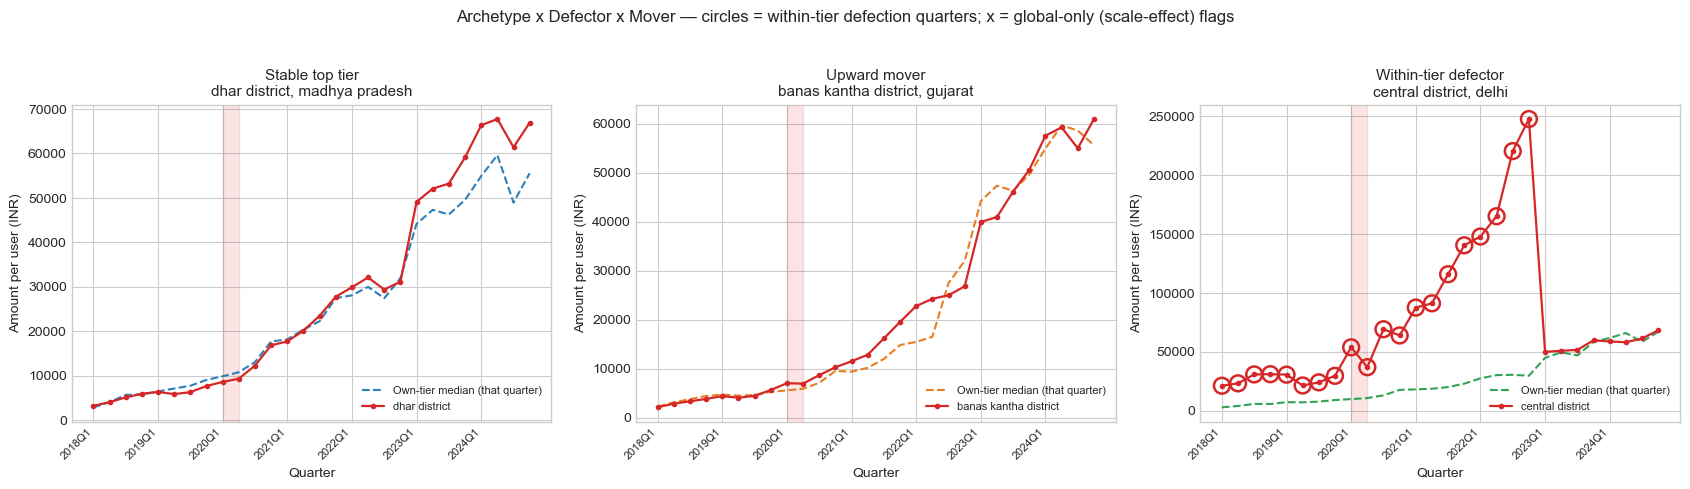

In [22]:
# --- Composite plot: each case-study district versus its tier median --

tier_median_traj = (
    district_panel.groupby(["tier", "year", "quarter", "period"])["amount_per_user"]
    .median().reset_index().sort_values(["tier", "year", "quarter"])
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.7), sharey=False)
ordered_periods = (
    district_panel[["year", "quarter", "period"]].drop_duplicates()
    .sort_values(["year", "quarter"])["period"].tolist()
)

tier_color = {1: PALETTE["blue"], 2: PALETTE["green"],
              3: PALETTE["orange"], 4: PALETTE["purple"],
              5: PALETTE["grey"], 6: PALETTE["red"]}

for ax, (role, info) in zip(axes, cases.items()):
    if info is None:
        ax.set_visible(False)
        continue
    dkey = info["district_id"]
    district_ts = (district_panel[district_panel["district_id"] == dkey]
                   .sort_values(["year", "quarter"]))
    # Quarter-specific peer median: for every quarter, look up the median of
    # whichever tier the district was in THAT quarter. This is the faithful
    # peer reference for movers (whose tier changes mid-panel); plotting a
    # single dominant-tier median throughout would hide the mover story.
    med_ts = district_ts.merge(
        tier_median_traj.rename(columns={"amount_per_user": "tier_med"}),
        on=["tier", "year", "quarter", "period"], how="left",
    ).sort_values(["year", "quarter"])
    dominant_tier = int(district_ts["tier"].mode().iloc[0])

    # Plot the quarter-specific tier median as the peer reference line.
    ax.plot(
        [ordered_periods.index(p) for p in med_ts["period"]],
        med_ts["tier_med"].values,
        color=tier_color.get(dominant_tier, PALETTE["grey"]),
        linestyle="--", linewidth=1.5,
        label="Own-tier median (that quarter)",
    )
    # Plot district trajectory
    ax.plot(
        [ordered_periods.index(p) for p in district_ts["period"]],
        district_ts["amount_per_user"].values,
        color=PALETTE["red"], marker="o", markersize=3, linewidth=1.6,
        label=info["district_name"],
    )

    # Ring within-tier (cluster-conditioned) defection quarters
    defects = panel[(panel["district_id"] == dkey) & (panel["wt_consensus"] == 1)]
    for _, r in defects.iterrows():
        ax.scatter(
            ordered_periods.index(r["period"]),
            r["amount_per_user"],
            facecolor="none", edgecolor=PALETTE["red"],
            s=130, linewidth=1.8, zorder=5,
        )

    # Faint cross for global-only flags (i.e. flagged by baseline but NOT within-tier -- scale artefacts)
    scale_only = panel[
        (panel["district_id"] == dkey)
        & (panel["consensus"] == 1)
        & (panel["wt_consensus"] == 0)
    ]
    for _, r in scale_only.iterrows():
        ax.scatter(
            ordered_periods.index(r["period"]),
            r["amount_per_user"],
            marker="x", color=PALETTE["grey"],
            s=55, linewidth=1.2, zorder=4,
        )

    # COVID band for context
    covid_x_start = ordered_periods.index("2020Q1")
    covid_x_end = ordered_periods.index("2020Q2")
    ax.axvspan(covid_x_start, covid_x_end, alpha=0.12, color=PALETTE["red"])

    ax.set_title(f"{role}\n{info['district_name']}, {info['state_name']}", fontsize=11)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Amount per user (INR)")
    tick_idx = list(range(0, len(ordered_periods), 4))
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([ordered_periods[i] for i in tick_idx],
                       rotation=45, ha="right", fontsize=8)
    ax.legend(loc="best", fontsize=8, framealpha=0.9)

plt.suptitle(
    "Archetype x Defector x Mover — circles = within-tier defection quarters; "
    "x = global-only (scale-effect) flags",
    fontsize=12, y=1.03,
)
plt.tight_layout()
plt.show()


### What the three districts tell us

- **The stable top-tier member** settles into Tier 1 early in the panel and tracks its Tier-1 median closely for the rest of the window. The global baseline flags it in multiple quarters (grey `x` marks) because its *scale* is unusual nationally, but the within-tier detector clears it — **zero within-tier circles**. This is the cleanest illustration of the §6 thesis: a district the naive baseline mislabels as an "anomaly" that the cluster-conditioned view correctly exonerates as a well-behaved archetype member.
- **The upward mover** starts tracking its tier's reference median and gradually pulls away *upward* as it transitions to the higher archetype — the curve visibly diverges from the dashed band rather than oscillating around it. It triggers neither global nor within-tier flags; mobility here is a *quiet* continuous climb, not a shock.
- **The persistent within-tier defector** has multiple ringed quarters — repeated, across-detector deviations from its own archetype's median — and its final tier label has drifted from its starting tier. This is the signal the baseline alone can miss on *combination*: a district that might or might not be a scale outlier but is *additionally* out of step with its peer archetype, often preceding an actual tier move. The direction (upward vs downward) tells us whether it is a candidate for expansion focus or for data-quality / shock review.

### The allocation takeaway

A fintech or development-finance actor deciding how to allocate expansion capital across India should not think "national uniform rollout". The archetype-plus-defector view gives three actionable lenses:

1. **Archetype-targeted product design.** Each archetype has its own unit economics — Tier 1 wants credit and merchant depth, Tier 3 wants engagement and reach. The stable map tells you where to design for.
2. **Movers over stayers.** The districts that are moving between archetypes are the growth story; capital should over-index on them relative to the stable core.
3. **Within-tier defector watch-list as a due-diligence queue.** A ranked, evidence-backed shortlist — districts that break from their archetype *and* (from the §6 mobility analysis) are disproportionately likely to cross archetypes — replaces a scattergun screen with a prioritised set of named districts.


## 8. Limitations — what this notebook cannot say

Honest scope-setting:

- **Platform bias.** PhonePe is the largest UPI app by volume but it is not all of UPI, and UPI is not all of digital payments. The archetypes and defectors are *PhonePe* archetypes and *PhonePe* defectors. Generalising to "India's digital-payments market" is a reasonable directional inference, not a proof.
- **Aggregation bias.** PhonePe Pulse is aggregated to district / state totals. We cannot infer individual-user behaviour from these aggregates; ecological-fallacy risks apply.
- **No ground-truth anomalies.** The three-detector consensus (global *and* within-tier) is a *triangulation*, not a validation. We do not claim precision or recall — we claim that districts flagged by multiple independent methods in multiple quarters, relative to both global and own-tier peers, deserve attention.
- **Clustering assumes a stationary behavioural typology.** Within-quarter standardisation partially addresses this: tiers are re-assigned every quarter, so a district can change tier when its behaviour changes. But the *definition* of "what tier 1 looks like" is fixed by the K-Means centroids; if that definition drifts materially over time, late-period tier labels are only as good as that assumption.
- **Cluster-conditioned detection needs adequate within-tier sample size.** When a `(year × quarter × tier)` cell has fewer than 10 districts, we skip the detectors for that cell — a (small) portion of district-quarters therefore has no within-tier score. LOF also degrades when the peer group is small; `n_neighbors` is capped at `min(15, n-1)` to handle this.
- **Mobility analysis is observational.** The finding that early within-tier defectors are disproportionately likely to change tier by 2024Q4 is a *correlation* on the full panel. It is consistent with defection being a leading indicator, but a causal claim would require an out-of-sample or held-out design we do not attempt here.
- **Category signal is unused in the clustering / anomaly pipeline.** We use only `(txns_per_user, amount_per_user, opens_per_user)`. Incorporating merchant-vs-P2P category mix at the district level (when available) is a clean extension that would add a behavioural dimension orthogonal to volume.


## 9. Conclusions

**The big question.** Do Indian districts cluster into a small, interpretable set of behavioural archetypes; how much do district *assignments* under that typology churn over five years; and which districts persistently defy their own archetype's norms — potentially foreshadowing mobility between archetypes?

**One-sentence answer.** Yes: districts fall into a small number of stable, user-normalised archetypes; a narrow set of districts persistently *defects* from their archetype's norm when measured against own-tier peers rather than the whole country; and early-period defectors disproportionately end up moving between archetypes — so the two phases are really one story about how the archetype map evolves at its edges.

**Phase-by-phase.**

- **Phase 1 — Archetypes (WHO).** K-Means on within-quarter standardised, PCA-whitened user-normalised features produces interpretable tiers. The silhouette-optimal k is reported in-cell; we adopt **k=3** regardless because it preserves the middle ("upward mover") archetype that is the heart of the growth story, and we document the silhouette trade-off explicitly (exact distance from peak is printed by the silhouette cell). District *assignments* are **not** mostly stable at the district level — only ~40% of districts stay in the same tier between 2019Q4 and 2024Q4, so the majority cross a tier boundary over the window. What is stable is the archetype structure (the three tiers persist); the population inside each tier churns. Typology stability — invariance of centroids under a different time-window refit — is untested and left as a limitation.
- **Phase 2 — Defectors (WHERE).** The global baseline detector (z / Isolation Forest / LOF in consensus) mostly flags districts whose *scale* is unusual — tier-1 megacities and tiny outliers. Re-running the same three detectors *inside each (year × quarter × tier) cell* strips the scale effect and surfaces behavioural defection. The cluster-conditioned persistent watch-list is a small, named, ranked set, split by direction (upward defectors = outperform their tier; downward = underperform). Districts with 3+ early-period (2018–2019) within-tier defection quarters move tier at ~65.9% vs ~60.7% for non-defectors — a +5.1pp / 1.08× lift that is directionally consistent with the defection-foreshadows-mobility hypothesis but small in magnitude, with n=41 defectors vs 588 non-defectors. We treat this as a candidate signal worth out-of-sample validation, not a confirmed leading indicator.

**Answer to the motivating claim.** India is not one digital-payments ecosystem. It is a small set of behavioural archetypes whose *structure* is interpretable and stable in composition, while district *assignments* churn considerably — roughly 60% of districts cross a tier boundary in five years. A small watch-list of districts persistently deviates from its archetype's norms, and those defectors *may* be over-represented among future movers (suggestive +5pp lift, pending out-of-sample confirmation).

**Next steps.**

1. **Out-of-sample mobility validation.** Re-fit the archetype map on 2018–2021 only, freeze it, compute within-tier defection on 2021–2022, and test whether it predicts 2023–2024 tier transitions on held-out quarters. This turns the observational mobility finding into a genuine predictive test.
2. **Hierarchical spatiotemporal forecasting.** Use archetype membership as a hierarchical prior in a district-level forecasting model; the archetype map would act as a regulariser that borrows strength across districts in the same tier.
3. **Defector-to-event linking.** Join the within-tier watch-list to external event data (policy changes, natural disasters, app-service outages) to split "unknown defections" into known-cause buckets.
4. **Category-aware archetypes.** Extend the clustering feature matrix with merchant-vs-P2P mix at the district level to let the archetype map reflect *what* people pay for, not only *how much*.


## Appendix A — Pipeline Integrity Tests

Single cell containing the consolidated assertion checks. Verifies that the data pipeline, clustering outputs, and both global and cluster-conditioned anomaly outputs all satisfy basic invariants.


In [23]:
# --- Consolidated integrity tests -------------------------------------

# Coverage
assert len(available_yq) == 28, f"Expected 28 quarters; got {len(available_yq)}."
assert len(district_panel) > 15_000, f"District panel unexpectedly small: {len(district_panel):,}."
assert district_panel[FEATURES].isna().sum().sum() == 0

# Cluster outputs
assert district_panel["tier"].between(1, best_k).all()
assert district_panel["tier"].nunique() == best_k
assert len(set(tier_order)) == best_k, "Tier ordering must be unique."

# Global-baseline anomaly outputs
for col in ("z_flag", "if_flag", "lof_flag", "consensus"):
    assert set(panel[col].unique()).issubset({0, 1}), f"{col} contains non-binary values."
assert panel["votes"].between(0, 3).all()
assert 0 < panel["consensus"].mean() < 0.15, "Global consensus rate outside plausible range."

# Cluster-conditioned (within-tier) anomaly outputs
for col in ("wt_z_flag", "wt_if_flag", "wt_lof_flag", "wt_consensus"):
    assert set(panel[col].unique()).issubset({0, 1}), f"{col} contains non-binary values."
assert panel["wt_votes"].between(0, 3).all()
# Within-tier consensus rate is computed over eligible cells only (skipping tiny tier-quarter cells).
eligible_wt = panel[~panel["wt_if_score"].isna()]
assert len(eligible_wt) > 0.9 * len(panel), "Too many tier-quarter cells were skipped."
assert 0 < eligible_wt["wt_consensus"].mean() < 0.15, \
    "Within-tier consensus rate outside plausible range."

# Watch-lists
assert (global_watch["n_flagged_quarters"] >= 3).all()
assert (wt_watch["n_flagged_quarters"] >= 3).all()
assert wt_watch["dominant"].isin(
    {"UPWARD (outperforms own tier)", "DOWNWARD (underperforms own tier)", "mixed"}
).all()

# Case studies
for col in ("n_q_flagged_global", "n_q_flagged_within_tier"):
    assert case_table[col].ge(0).all()
assert len(case_table) >= 2, "Need at least two case studies."

# Mobility linkage: the trajectory column is well-formed.
assert set(traj.unique()).issubset({"upward", "downward", "stayed"})

print("Appendix A — All integrity tests passed.")
print(f"  panel rows:              {len(district_panel):,}")
print(f"  tiers:                   {best_k}")
print(f"  global watch list:       {len(global_watch)} districts")
print(f"  within-tier watch list:  {len(wt_watch)} districts")
print(f"  global consensus rate:       {panel['consensus'].mean():.2%}")
print(f"  within-tier consensus rate:  {eligible_wt['wt_consensus'].mean():.2%}")


Appendix A — All integrity tests passed.
  panel rows:              20,604
  tiers:                   3
  global watch list:       76 districts
  within-tier watch list:  94 districts
  global consensus rate:       3.31%
  within-tier consensus rate:  3.98%


## Appendix B — Collaboration Declaration

1. **Collaborators:** None (individual work).
2. **Web sources:** PhonePe Pulse repository (https://github.com/PhonePe/pulse); scikit-learn documentation.
3. **AI tools:** Claude Code (Anthropic) — used for structural iteration on the notebook narrative, cell organisation, and code review. All final analytical choices (clustering pipeline, global-vs-within-tier anomaly design, consensus rule, mobility-linkage design, case-study selection logic) were made by the author.
4. **Paper citations:**
   - Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). *Isolation Forest.* ICDM 2008: 413–422.
   - Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). *LOF: Identifying density-based local outliers.* SIGMOD Record 29(2): 93–104.
5. **Repository.** https://github.com/ShashankC10/phonePePulseEDA
